# 8주차 | GPT 모델 실습

> **선수지식**: 7주차(Self-Attention, Transformer Encoder)  
> **이번 목표**: GPT의 구조를 이해하고, 한국어 GPT 모델로 텍스트를 생성해본다

### 7주차 vs 8주차

```python
# 7주차: Encoder — 모든 단어를 양방향으로 참조 → 분류
# 8주차: Decoder — 왼쪽만 참조 (미래를 가림) → 생성
#
# 차이는 딱 하나: Attention에 마스크를 씌우는 것
```

| 파트 | 내용 |
|------|------|
| Part 1 | Causal Mask — "미래를 못 본다" |
| Part 2 | 미니 GPT 직접 만들기 |
| Part 3 | 한국어 GPT로 텍스트 생성 |
| Part 4 | 프롬프트 엔지니어링 |
| Part 5 | 8주 전체 정리 |

---
## Part 1. Causal Mask — GPT가 Encoder와 다른 점

7주차 Encoder에서는 모든 단어가 서로를 볼 수 있었습니다.  
GPT에서는 **삼각형 마스크**를 씌워서 미래 단어를 가립니다.  
왜? 텍스트를 생성할 때 미래 단어는 **아직 없으니까요.**

/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5995/2964241196.py:33: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight

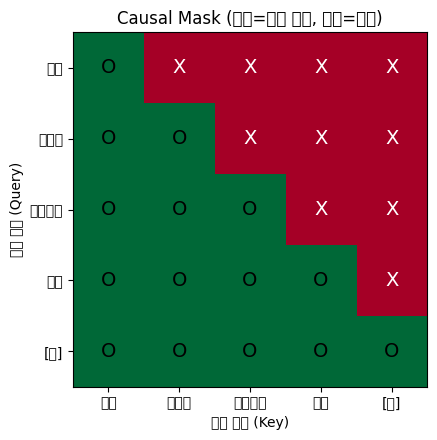

각 행은 자기보다 왼쪽(과거)만 참조 가능!
이것이 GPT가 텍스트를 '생성'할 수 있는 핵심 구조


In [1]:
# 1️⃣ Causal Mask 시각화
#
# 7주차 Encoder: 모든 칸이 O (양방향)
# 8주차 GPT:     아래 삼각형만 O (왼쪽만 참조)

import torch
import matplotlib.pyplot as plt

# 마스크 생성: 상삼각 부분 = True(가림)
seq_len = 5
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

tokens = ["나는", "영화를", "재미있게", "봤다", "[끝]"]

fig, ax = plt.subplots(figsize=(5, 4.5))
display = (~mask).float().numpy()  # O=초록, X=빨강
ax.imshow(display, cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens, fontsize=10)
ax.set_yticklabels(tokens, fontsize=10)
ax.set_xlabel("참조 대상 (Key)")
ax.set_ylabel("현재 위치 (Query)")
ax.set_title("Causal Mask (초록=참조 가능, 빨강=가림)")

for i in range(seq_len):
    for j in range(seq_len):
        label = "O" if not mask[i][j] else "X"
        color = "black" if not mask[i][j] else "white"
        ax.text(j, i, label, ha="center", va="center", fontsize=14, color=color)

plt.tight_layout()
plt.show()

print("각 행은 자기보다 왼쪽(과거)만 참조 가능!")
print("이것이 GPT가 텍스트를 '생성'할 수 있는 핵심 구조")

---
## Part 2. 미니 GPT 직접 만들기

GPT의 사전학습 = **"다음 단어 예측"** 을 아주 작은 규모로 직접 만들어봅니다.

```
학습 방식:
  입력: "나는"           → 정답: "영화를"
  입력: "나는 영화를"     → 정답: "좋아한다"
```

> 7주차 Transformer 코드를 아는 분이라면,  
> 달라지는 부분은 **causal_mask 한 줄**과 **출력층**뿐입니다.

In [2]:
# 2️⃣ 학습 데이터 — 간단한 문장 4개
import torch
import torch.nn as nn

sentences = [
    "나는 영화를 좋아한다",
    "나는 음악을 좋아한다",
    "그는 영화를 싫어한다",
    "그는 음악을 싫어한다",
]

# 어휘 사전 만들기
all_tokens = sorted(set(w for s in sentences for w in s.split()))
word2idx = {w: i+1 for i, w in enumerate(all_tokens)}
word2idx["<PAD>"] = 0
idx2word = {i: w for w, i in word2idx.items()}

print(f"어휘 사전: {word2idx}")
print(f"총 {len(word2idx)}개 단어")

어휘 사전: {'그는': 1, '나는': 2, '싫어한다': 3, '영화를': 4, '음악을': 5, '좋아한다': 6, '<PAD>': 0}
총 7개 단어


In [5]:
# 3️⃣ "다음 단어 예측" 학습 쌍 만들기
#
# 예) "나는 영화를 좋아한다"에서:
#   입력: [나는]         → 정답: 영화를
#   입력: [나는, 영화를]  → 정답: 좋아한다

MAX_LEN = 4
X_train = []  # 입력 시퀀스
y_train = []  # 다음 단어 (정답)

for sent in sentences:
    tokens = [word2idx[w] for w in sent.split()]
    for i in range(1, len(tokens)):
        # 입력: 0~i-1번째 단어 (왼쪽 패딩)
        inp = tokens[:i]
        padded = [0] * (MAX_LEN - len(inp)) + inp
        X_train.append(padded)
        # 정답: i번째 단어
        y_train.append(tokens[i])

X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)

# 학습 데이터 확인
print(f"학습 샘플: {len(X_train)}개\n")
for i in range(min(6, len(X_train))):
    words_in = [idx2word[t.item()] for t in X_train[i] if t.item() != 0]
    word_out = idx2word[y_train[i].item()]
    print(f'  {str(words_in):30s} → "{word_out}"')

학습 샘플: 8개

  ['나는']                         → "영화를"
  ['나는', '영화를']                  → "좋아한다"
  ['나는']                         → "음악을"
  ['나는', '음악을']                  → "좋아한다"
  ['그는']                         → "영화를"
  ['그는', '영화를']                  → "싫어한다"


In [6]:
# 4️⃣ 미니 GPT 모델 정의
#
# 7주차 TransformerClassifier와 비교:
#   [같은 점] Embedding, TransformerEncoder 사용
#   [다른 점 1] causal_mask 추가 (미래를 가림)
#   [다른 점 2] 출력이 sigmoid(1개) 대신 vocab_size개 (다음 단어 확률)

import math

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, d_model)  # 위치 임베딩

        # Transformer (7주차와 같은 부품)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)

        # 출력: 어휘 크기만큼 (다음 단어의 확률 분포)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape

        # 임베딩 + 위치
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(pos)

        # ★ 핵심 차이: Causal Mask (미래를 못 보게!)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()

        # Transformer 실행
        x = self.transformer(x, mask=causal_mask)

        # 마지막 위치 → 다음 단어 예측
        logits = self.fc_out(x[:, -1, :])  # (B, vocab_size)
        return logits


mini_gpt = MiniGPT(
    vocab_size=len(word2idx),
    d_model=32,     # 임베딩 차원
    num_heads=4,    # Attention 헤드 수
    num_layers=2,   # 블록 반복 수
    max_len=MAX_LEN
)
print(mini_gpt)
print(f"\n파라미터: {sum(p.numel() for p in mini_gpt.parameters()):,}개")

MiniGPT(
  (token_emb): Embedding(7, 32, padding_idx=0)
  (pos_emb): Embedding(4, 32)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=32, out_features=7, bias=True)
)

파라미터: 25,991개


In [7]:
# 5️⃣ 미니 GPT 학습
#
# 학습 루프는 6~7주차와 같은 패턴!
# 차이: BCELoss(이진) → CrossEntropyLoss(다중 클래스)
#   → "다음 단어가 어휘 중 뭐냐" = 다중 분류 문제

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mini_gpt.parameters(), lr=0.005)

for epoch in range(200):
    mini_gpt.train()
    logits = mini_gpt(X_train)         # 1. 순전파
    loss = criterion(logits, y_train)  # 2. 손실
    optimizer.zero_grad()              # 3. 초기화
    loss.backward()                    # 4. 역전파
    optimizer.step()                   # 5. 업데이트

    if (epoch + 1) % 50 == 0:
        acc = (logits.argmax(dim=1) == y_train).float().mean()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc.item():.0%}")

print("\n학습 완료!")

Epoch  50 | Loss: 0.3947 | Acc: 62%
Epoch 100 | Loss: 0.3419 | Acc: 75%
Epoch 150 | Loss: 0.3766 | Acc: 75%
Epoch 200 | Loss: 0.3203 | Acc: 75%

학습 완료!


In [9]:
# 6️⃣ 미니 GPT로 텍스트 생성!
#
# 자기회귀 생성: 한 단어씩 만들고, 만든 단어를 다시 입력에 추가

def generate(start_words, max_generate=3):
    """시작 단어들로부터 다음 단어를 하나씩 생성"""
    mini_gpt.eval()
    tokens = [word2idx.get(w, 0) for w in start_words]
    result = list(start_words)

    for _ in range(max_generate):
        padded = [0] * (MAX_LEN - len(tokens)) + tokens[-MAX_LEN:]
        inp = torch.tensor([padded], dtype=torch.long)

        with torch.no_grad():
            logits = mini_gpt(inp)
            next_id = logits.argmax(dim=1).item()  # 가장 확률 높은 단어

        if next_id == 0:
            break
        tokens.append(next_id)
        result.append(idx2word[next_id])

    return " ".join(result)


print("=== 미니 GPT 텍스트 생성 ===")
print()
print(f'  "나는"         → {generate(["나는"])}')
print(f'  "그는"         → {generate(["그는"])}')
print(f'  "나는 음악을"  → {generate(["나는", "음악을"])}')
print(f'  "그는 영화를"  → {generate(["그는", "영화를"])}')
print()
print("학습한 패턴대로 다음 단어를 예측합니다!")
print("이것이 GPT의 핵심 원리 — 규모만 수억 배 키운 것이 ChatGPT")

=== 미니 GPT 텍스트 생성 ===

  "나는"         → 나는 영화를 좋아한다 영화를
  "그는"         → 그는 영화를 싫어한다 영화를
  "나는 음악을"  → 나는 음악을 좋아한다 영화를 좋아한다
  "그는 영화를"  → 그는 영화를 싫어한다 영화를 영화를

학습한 패턴대로 다음 단어를 예측합니다!
이것이 GPT의 핵심 원리 — 규모만 수억 배 키운 것이 ChatGPT


---
## Part 3. 한국어 GPT로 진짜 텍스트 생성

위의 미니 GPT는 단어 6개짜리 장난감이었습니다.  
이제 **실제 사전학습된 한국어 GPT** 모델을 사용해봅시다.

`skt/kogpt2-base-v2`는 SKT에서 한국어 텍스트로 학습한 GPT-2 모델입니다.  
**무료**이고, Colab 무료 GPU로도 실행 가능합니다.

In [10]:
# 7️⃣ 설치 & 한국어 GPT 텍스트 생성
#
# Colab에서 실행하세요. 최초 실행 시 모델 다운로드에 1~2분 걸립니다.

# !pip install transformers

from transformers import pipeline

# 한국어 GPT-2 모델 로드
generator = pipeline(
    "text-generation",
    model="skt/kogpt2-base-v2",  # SKT 한국어 GPT-2
)

# 텍스트 생성
results = generator(
    "인공지능 기술이 발전하면",   # 시작 문장
    max_length=80,              # 최대 길이
    num_return_sequences=3,     # 3개 생성
    do_sample=True,             # 확률적 샘플링
    temperature=0.8,            # 창의성 조절
)

print("=== 한국어 GPT 텍스트 생성 ===")
for i, r in enumerate(results, 1):
    print(f"\n[생성 {i}]")
    print(r["generated_text"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'temperature', 'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== 한국어 GPT 텍스트 생성 ===

[생성 1]
인공지능 기술이 발전하면�š��n�����n�����n���n�����n����n���n����n���n��
우르띠에:▁우르띠에▁(▁▁)▁,▁루에:▁우르띠에▁(▁▁)▁의▁방언으로,▁우크라이나의▁민속에▁영향을▁주는▁것으로▁알려져▁있다.
우르띠에:▁우르띠에▁(▁▁)
우르띠에:▁우르띠에▁(▁▁)▁의▁방언으로,▁우크라이나의▁민속에▁영향을▁주는▁것으로▁알려져▁있다.
우르띠에:▁우르띠에▁(▁▁)▁의▁방언으로,▁우르띠에▁(▁▁)
우르띠에:▁우르띠에▁(▁▁)▁의▁방언으로,▁우크라이나의▁민속에▁영향을▁주는▁것으로▁알려져▁있다.
우르띠에:▁우르띠에▁(▁▁)▁의▁방언으로,▁키예프▁출신의▁우크라이나▁국립음악원▁원장이자▁키예프▁국립음악원▁원장이자▁키예프▁국립음악원▁원장이자,▁우크라이나의▁민속학자가▁쓴▁최초의▁프랑스어▁소설▁《우르띠에

[생성 2]
인공지능 기술이 발전하면š�ś��t�t��t�t��t�t�v�tǐt�t�tt�t�t�tt�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�tt�t�t�t�t�tǐt�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t

[생성 3]
인공지능 기술이 발전하면��
����n����š
��ǒ���
�����
������
������
�����������!
����▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁-▁

In [11]:
# 8️⃣ Temperature 비교 — 창의성 조절
#
# temperature가 낮으면: 가장 확률 높은 단어만 선택 (안전, 반복적)
# temperature가 높으면: 다양한 단어도 선택 (창의적, 엉뚱할 수도)

prompt = "오늘 날씨가 좋아서"

print(f'프롬프트: "{prompt}"\n')

for temp in [0.3, 0.7, 1.2]:
    result = generator(
        prompt,
        max_length=60,
        do_sample=True,
        temperature=temp,
        num_return_sequences=1,
    )
    text = result[0]["generated_text"]
    print(f"Temperature={temp}:")
    print(f"  {text}")
    print()

print("0.3: 보수적, 예측 가능")
print("0.7: 적당한 다양성 (추천값)")
print("1.2: 창의적, 엉뚱할 수 있음")

Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


프롬프트: "오늘 날씨가 좋아서"



Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=0.3:
  오늘 날씨가 좋아서



Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=0.7:
  오늘 날씨가 좋아서,▁P��ti,▁P��,▁P�š�,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P�ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti,▁P��ti

Temperature=1.2:
  오늘 날씨가 좋아서n�c�
Le▁Aeroi�m��n�-Li�m�rie▁du▁Fro�br�▁�l�x�in�x�d�r�,▁J�rm�v�trou▁vais�n�v��r
�ll�x�n�v�tōi�re▁du▁N�rif�▁de▁couv�le▁d�c�u,▁J�te-fi�t�le▁d'�v�d�i�re,▁K�n�li.
Qeevei�riu.j�chi-M�re/F�l�.E-L�e.
�l�n�p�g��s▁à▁�die▁l�u�trou▁m�er�▁tr�r
K�m�n�d�c�▁c�in�m�e/F�l�?E-F�l�,▁�de�r�en
/L�tidele▁de▁ch�ini�n�
Ne

0.3: 보수적, 예측 가능
0.7: 적당한 다양성 (추천값)
1.2: 창의적, 엉뚱할 수 있음


In [12]:
# 9️⃣ 다양한 프롬프트로 생성 실험
#
# 시작 문장에 따라 생성 결과가 어떻게 달라지는지 비교해봅시다.

prompts = [
    "대한민국의 수도는",
    "맛있는 음식을 먹으면",
    "프로그래밍을 배우려면",
    "행복한 삶을 위해서는",
]

print("=== 다양한 프롬프트 실험 ===\n")
for prompt in prompts:
    result = generator(
        prompt,
        max_length=50,
        do_sample=True,
        temperature=0.7,
        num_return_sequences=1,
    )
    print(f'입력: "{prompt}"')
    print(f'생성: {result[0]["generated_text"]}')
    print()

Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== 다양한 프롬프트 실험 ===



Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력: "대한민국의 수도는"
생성: 대한민국의 수도는���������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������



Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력: "맛있는 음식을 먹으면"
생성: 맛있는 음식을 먹으면�����t�t�tt�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t�t



Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력: "프로그래밍을 배우려면"
생성: 프로그래밍을 배우려면�n�)는▁프랑스의▁축구▁국가대표팀이다.
현재까지▁17개의▁클럽에서▁활약▁중이다.
2004년,▁프랑스의▁리그컵에▁첫▁출전하여▁A매치▁8강에서▁만나▁팀을▁우승한▁뒤▁2006년,▁A매치▁A매치▁A매치▁4강에서▁만나▁세리에▁A▁우승컵을▁거머쥐었다.
2007년,▁A매치▁A매치▁4강에서▁만나▁만난▁팀이▁A매치▁A매치▁4강에서▁만나▁팀을▁우승했다.
2009년,▁A매치▁A매치▁4강에서▁만나▁만난▁팀이▁A매치▁A매치▁4강에서▁만나▁팀을▁우승시켰다.
2009년,▁A매치▁A매치▁4강에서▁만난▁팀이▁A매치▁A매치▁A매치▁4강에서▁만나▁팀을▁우승했다.
2012년,▁A매치▁A매치▁4강에서▁만난▁팀이▁A매치▁A매치▁4강에서▁만나▁팀을▁우승시켰다.
2013년,▁A매치▁A매치▁4강에서▁만난▁팀이▁A매치▁A매치▁A매치▁4강에서▁만나▁팀을▁우승시켰다.
2015년,▁A매치▁A매치▁4강에서▁만난▁팀이▁A매치▁A매치▁4강에서▁만나▁팀을▁우승시켰다.
2016년,▁A매치▁A매치▁4강에서▁만난▁팀이▁A매치▁A매치▁4강

입력: "행복한 삶을 위해서는"
생성: 행복한 삶을 위해서는����������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������



---
## Part 4. 프롬프트 엔지니어링

GPT-3 이후 모델이 충분히 커지면, **학습 없이 질문만으로** 과제를 수행합니다.

> 💡 아래 프롬프트는 `skt/kogpt2`보다는 **ChatGPT나 Claude** 같은  
> 대형 모델에서 잘 작동합니다. 여기서는 "이렇게 설계한다"는 것을 경험합니다.

### Zero-shot vs Few-shot

```
Zero-shot: 예시 없이 바로 질문
  "이 리뷰의 감성은? 리뷰: 재미있다 → 감성:"

Few-shot: 예시를 몇 개 보여준 뒤 질문
  "리뷰: 최고! → 긍정
   리뷰: 별로 → 부정
   리뷰: 좋았다 → "
```

In [13]:
# 🔟 프롬프트 설계 실습
#
# 아래는 실제로 ChatGPT/Claude에서 사용할 수 있는 프롬프트입니다.
# 직접 수정해보고, ChatGPT에 입력해서 테스트해보세요!

# --- 1) 감성 분류 프롬프트 ---
prompt_sentiment = """
당신은 상품 리뷰 감성 분석 전문가입니다.
리뷰를 읽고 긍정/부정/중립 중 하나로 분류하세요.

예시:
리뷰: 품질 좋고 배송 빨라요 → 긍정
리뷰: 불량이고 환불 어렵다 → 부정
리뷰: 디자인은 좋은데 내구성이 약해요 → 중립

리뷰: 가격 대비 만족합니다 →
"""

# --- 2) 요약 프롬프트 ---
prompt_summary = """
다음 텍스트를 3줄로 요약하세요.
각 줄은 핵심 내용만 담아주세요.

텍스트: 인공지능(AI) 기술의 급격한 발전은 의료, 금융, 제조 등 다양한 산업 전반에 걸쳐 혁신적인 변화를 이끌어내고 있습니다. 특히 딥러닝 기반의 언어 모델은 인간 수준의 문장 생성 및 이해 능력을 갖추게 되었으며, 이는 생산성 향상에 크게 기여하고 있습니다. 그러나 개인정보 보호 및 AI 윤리 문제 등 해결해야 할 과제도 함께 대두되고 있습니다.

요약:
"""

# --- 3) 키워드 추출 프롬프트 ---
prompt_keyword = """
다음 텍스트에서 핵심 키워드 5개를 추출하세요.
쉼표로 구분하여 나열하세요.

텍스트: 인공지능(AI) 기술의 급격한 발전은 의료, 금융, 제조 등 다양한 산업 전반에 걸쳐 혁신적인 변화를 이끌어내고 있습니다. 특히 딥러닝 기반의 언어 모델은 인간 수준의 문장 생성 및 이해 능력을 갖추게 되었으며, 이는 생산성 향상에 크게 기여하고 있습니다. 그러나 개인정보 보호 및 AI 윤리 문제 등 해결해야 할 과제도 함께 대두되고 있습니다.

키워드:
"""

print("=== 프롬프트 설계 예시 ===")
print()
print("[감성 분류 프롬프트]")
print(prompt_sentiment)
print("설계 핵심:")
print("  1. 역할 부여 (감성 분석 전문가)")
print("  2. 분류 기준 명시 (긍정/부정/중립)")
print("  3. Few-shot 예시 3개")
print("  4. 출력 형식 지정 (→ 뒤에 답변)")

=== 프롬프트 설계 예시 ===

[감성 분류 프롬프트]

당신은 상품 리뷰 감성 분석 전문가입니다.
리뷰를 읽고 긍정/부정/중립 중 하나로 분류하세요.

예시:
리뷰: 품질 좋고 배송 빨라요 → 긍정
리뷰: 불량이고 환불 어렵다 → 부정
리뷰: 디자인은 좋은데 내구성이 약해요 → 중립

리뷰: 가격 대비 만족합니다 →

설계 핵심:
  1. 역할 부여 (감성 분석 전문가)
  2. 분류 기준 명시 (긍정/부정/중립)
  3. Few-shot 예시 3개
  4. 출력 형식 지정 (→ 뒤에 답변)


In [14]:
# 1️⃣1️⃣ KoGPT로 Few-shot 프롬프트 시도
#
# kogpt2는 작은 모델이라 프롬프트 성능이 제한적입니다.
# "이런 식으로 프롬프트를 설계한다"는 것을 경험하는 데 의의가 있습니다.

prompt = """다음은 영화 리뷰의 감성 분류 예시입니다.

리뷰: 정말 재미있는 영화였다
감성: 긍정

리뷰: 시간 낭비였다
감성: 부정

리뷰: 배우 연기가 좋았다
감성:"""

result = generator(
    prompt,
    max_length=len(prompt.split()) + 10,
    do_sample=False,
    num_return_sequences=1,
)

print("=== Few-shot 프롬프트 테스트 (KoGPT2) ===")
print(result[0]["generated_text"][-50:])  # 마지막 50자만
print()
print("kogpt2는 소규모 모델이라 정확하지 않을 수 있습니다.")
print("GPT-4나 Claude에서는 이 프롬프트로 정확하게 응답합니다.")
print()
print("직접 ChatGPT(chat.openai.com)나 Claude(claude.ai)에")
print("위 프롬프트를 붙여넣어 테스트해보세요!")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=32) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Few-shot 프롬프트 테스트 (KoGPT2) ===
.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�

kogpt2는 소규모 모델이라 정확하지 않을 수 있습니다.
GPT-4나 Claude에서는 이 프롬프트로 정확하게 응답합니다.

직접 ChatGPT(chat.openai.com)나 Claude(claude.ai)에
위 프롬프트를 붙여넣어 테스트해보세요!


---
## Part 5. 8주 전체 정리

### GPT 핵심 요약

```
GPT = Transformer + Causal Mask + 다음 단어 예측

7주차 Encoder:  양방향 참조 → 분류 (BERT)
8주차 Decoder:  왼쪽만 참조 → 생성 (GPT)

코드 차이: mask 한 줄 + 출력층 변경
```

### 세 가지 패러다임

```
패러다임 1: TF-IDF + ML         사람이 특성 설계    (1~5주차)
패러다임 2: 사전학습 + 파인튜닝   모델이 언어를 배움  (6~8주차)
패러다임 3: 프롬프트              질문만으로 해결     (GPT-3 이후)
```

### 8주간의 여정

```
[1주차] 입문
[2주차] 전처리            "텍스트를 깨끗하게"
[3주차] BoW, TF-IDF       "텍스트를 숫자로"
[4주차] ML 분류            "숫자로 분류"
[5주차] Word2Vec           "단어에 의미를"
[6주차] RNN, LSTM          "순서를 이해"
[7주차] Transformer        "문맥을 이해"
[8주차] GPT                "사전학습의 힘"
```

### 방법론 선택

| 상황 | 추천 |
|------|------|
| 데이터 적고 빠르게 | TF-IDF + ML |
| 순서 중요 | LSTM |
| 최고 성능 | BERT/GPT 파인튜닝 |
| 데이터 없음 | 프롬프트 (GPT API) |

---
## 📝 과제

### 과제 1: 한국어 GPT 텍스트 생성

다양한 시작 문장과 temperature로 텍스트를 생성하고 결과를 비교하세요.

### 과제 2: 프롬프트 설계

ChatGPT 또는 Claude에서 아래 3가지를 프롬프트로 해결하세요:
1. 감성 분류 (긍정/부정/중립)
2. 텍스트 요약 (3줄)
3. 키워드 추출 (5개)

각 과제: 프롬프트 설계 → 테스트 → 개선 과정을 기록하세요.

In [15]:
from transformers import pipeline

# 1. 한국어 GPT-2 모델 로드
generator = pipeline(
    "text-generation",
    model="skt/kogpt2-base-v2",
)

# 2. 다양한 프롬프트 및 Temperature 실험 설정
prompts = [
    "인공지능 기술이 발전하면",
    "오늘 날씨가 좋아서"
]
temperatures = [0.3, 0.7, 1.2]

print("=== 한국어 GPT 텍스트 생성 및 Temperature 비교 실험 ===\n")

for prompt in prompts:
    print(f'시작 프롬프트: "{prompt}"')
    print("-" * 50)
    for temp in temperatures:
        result = generator(
            prompt,
            max_new_tokens=40,                               # 순수하게 생성할 토큰 수 지정
            do_sample=True,                                  # 확률적 샘플링 활성화
            temperature=temp,                                # 창의성 조절
            num_return_sequences=1,
            pad_token_id=generator.tokenizer.eos_token_id    # 패딩 경고 방지
        )
        text = result[0]["generated_text"]
        print(f"▶ Temperature = {temp:<3} | {text}")
    print("\n" + "="*60 + "\n")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'num_return_sequences', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_n

=== 한국어 GPT 텍스트 생성 및 Temperature 비교 실험 ===

시작 프롬프트: "인공지능 기술이 발전하면"
--------------------------------------------------


Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


▶ Temperature = 0.3 | 인공지능 기술이 발전하면����������������������������������������


...

▶ Temperature = 1.2 | 인공지능 기술이 발전하면ō�ǔze,▁Paris:▁�n�sia:▁Eur�-Langi.,▁Paris:▁Berlin,▁1994-95.에▁소개되었지만,▁이


시작 프롬프트: "오늘 날씨가 좋아서"
--------------------------------------------------


Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


▶ Temperature = 0.3 | 오늘 날씨가 좋아서�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n


Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


▶ Temperature = 0.7 | 오늘 날씨가 좋아서�n��v�ǎi�v��n��tt�t�t�t�t�t�t�t�t�t�t�t
▶ Temperature = 1.2 | 오늘 날씨가 좋아서▁à▁m������,▁Tmm�n�i�▁(▁�▁)▁)
중국의▁한▁지역▁방언으로▁'위구르'(W




In [ ]:
# 상품 리뷰 감성 분류 (긍정/부정/중립)
# 초기 프롬프트 :
promprt = """
다음 리뷰를 긍정, 부정, 중립 중 하나로 분류해줘.
리뷰: 가격은 좀 비싼데 성능은 확실히 돈값 하네요.
"""

# 초기 테스트 결과:
"""
이 리뷰는 긍정입니다.
이유: 가격이 비싸다는 단점은 언급했지만, “성능은 확실히 돈값 한다”라는 표현으로 전체적으로 만족감을 드러내고 있습니다.
"""

# 개선된 프롬프트 (페르소나 및 Few-shot 추가):

prompt = """
당신은 쇼핑몰 데이터 분석가입니다.
다음 리뷰를 읽고 다른 설명 없이 오직 [긍정], [부정], [중립] 중 하나의 단어로만 답변하세요.

[예시]
리뷰: 배송도 빠르고 품질도 대만족! -> [긍정]
리뷰: 돈 아까워요 사지 마세요. -> [부정]
리뷰: 색상은 예쁜데 사이즈가 좀 작음 -> [중립]

리뷰: 가격은 좀 비싼데 성능은 확실히 돈값 하네요. -> ?
"""

# 최종 테스트 결과:
"[긍정]"

In [ ]:
# 텍스트 요약 (3줄 요약)

# 초기 프롬프트 :
prompt = """
다음 글을 3줄로 요약해줘.
텍스트:

오늘 오후 2시 33분쯤, 서울 서대문구 서소문 고가차도 철거 현장에서 상판 일부가 갑자기 무너져 내렸습니다.

60대 현장 관리소장과 50대 외부 전문가 등 2명이 현장에서 숨진 채 발견됐고, 잔해에 깔린 채 발견된 50대 감리단장은 심정지 상태로 병원에 옮겨졌지만 끝내 숨졌습니다.

서울시와 지자체 공무원 등 구조된 3명은 머리와 갈비뼈 등을 다쳐 치료를 받고 있습니다.

소방이 통제 중인 서소문 고가차로 현장입니다.

도로는 교각만 남긴 채로 형체를 알아볼 수 없이 무너져 내렸고, 도로엔 잔해가 가득한 상태입니다.

[김창태/최초 신고자 : 어마어마한 굉음 소리가 나면서 흙먼지가 어마어마하게 올라왔어요. 대형 사고 터졌구나 직감하고 119에 먼저 신고하고….]

사고 당시 현장에는 철거 작업 안전진단에 나선 인원 등 모두 13명이 있었는데, 7명은 무사히 대피한 걸로 파악됐습니다.

추가 붕괴 우려 탓에 경찰이 인근 도로를 통제하면서 일대 교통은 온종일 마비됐고, 서울역과 신촌역 사이 전차선 단전 영향으로 열차 운행도 곳곳에서 차질이 빚어졌습니다.

[최진우/서울시 도시기반시설본부 토목부장 : 바닥에 떨어진 건 신속히 잔재를 철거하고요. 복구는 철도공단과 협의를 해서…. 철거는 하루면 되는데 사전 절차 그런 것을 준비하는 게 있어서….]

1966년에 지어진 서소문 고가차도의 철거 공사는 지난해 9월 시작돼 다음 달 초 마무리 될 예정이었습니다.

"""

# 초기 테스트 결과:
"""
서울 서대문구 서소문 고가차도 철거 현장에서 상판 일부가 붕괴해 3명이 숨지고 3명이 다쳤습니다.
사고 당시 현장에는 총 13명이 있었으며, 추가 붕괴 우려로 도로와 철도 운행까지 큰 차질이 발생했습니다.
1966년에 지어진 서소문 고가차도는 지난해부터 철거 중이었으며, 다음 달 공사 완료 예정이었습니다.
"""

# 개선된 프롬프트 (스타일 및 글자 수 제약 추가):

prompt = """
당신은 핵심만 찌르는 전문 편집자입니다.
제시된 텍스트를 다음 규칙에 맞게 요약하세요.

[규칙]
1. 반드시 정확히 3개의 행(줄)으로 요약할 것.
2. 각 줄은 명사형 어미(~함, ~임)로 끝나는 개조식 표현을 쓸 것.
3. 각 줄의 시작은 '- ' 기호로 시작하고, 한 줄당 공백 포함 30자 이내로 작성할 것.

텍스트:

오늘 오후 2시 33분쯤, 서울 서대문구 서소문 고가차도 철거 현장에서 상판 일부가 갑자기 무너져 내렸습니다.

60대 현장 관리소장과 50대 외부 전문가 등 2명이 현장에서 숨진 채 발견됐고, 잔해에 깔린 채 발견된 50대 감리단장은 심정지 상태로 병원에 옮겨졌지만 끝내 숨졌습니다.

서울시와 지자체 공무원 등 구조된 3명은 머리와 갈비뼈 등을 다쳐 치료를 받고 있습니다.

소방이 통제 중인 서소문 고가차로 현장입니다.

도로는 교각만 남긴 채로 형체를 알아볼 수 없이 무너져 내렸고, 도로엔 잔해가 가득한 상태입니다.

[김창태/최초 신고자 : 어마어마한 굉음 소리가 나면서 흙먼지가 어마어마하게 올라왔어요. 대형 사고 터졌구나 직감하고 119에 먼저 신고하고….]

사고 당시 현장에는 철거 작업 안전진단에 나선 인원 등 모두 13명이 있었는데, 7명은 무사히 대피한 걸로 파악됐습니다.

추가 붕괴 우려 탓에 경찰이 인근 도로를 통제하면서 일대 교통은 온종일 마비됐고, 서울역과 신촌역 사이 전차선 단전 영향으로 열차 운행도 곳곳에서 차질이 빚어졌습니다.

[최진우/서울시 도시기반시설본부 토목부장 : 바닥에 떨어진 건 신속히 잔재를 철거하고요. 복구는 철도공단과 협의를 해서…. 철거는 하루면 되는데 사전 절차 그런 것을 준비하는 게 있어서….]

1966년에 지어진 서소문 고가차도의 철거 공사는 지난해 9월 시작돼 다음 달 초 마무리 될 예정이었습니다.
"""

# 최종 테스트 결과:
"""
서소문 고가차도 붕괴 발생함
철거 현장서 3명 사망함
교통·열차 운행 차질 빚음
"""

In [17]:
# 핵심 키워드 추출 (5개)

# 초기 프롬프트 :
prompt = """
다음 글에서 핵심 키워드 5개 뽑아줘.
텍스트: 최근 며칠 사이에도 생성형 인공지능(AI) 기술은 무서운 속도로 진화하고 있습니다. 오픈AI의 GPT 시리즈나 앤트로픽의 클로드(Claude) 같은 거대 언어 모델(LLM)은 이제 단순한 문장 생성을 넘어 인간 고유의 영역이라 여겨졌던 추론, 코딩, 창작 영역까지 깊숙이 침투했습니다. 이러한 모델들의 급격한 성장은 수천억 개의 파라미터(매개변수)와 방대한 인터넷 데이터를 기반으로 한 대규모 사전학습(Pre-training) 덕분입니다.

그러나 이처럼 화려한 발전 뒤에는 치명적인 한계점과 기술적 과제들이 그림자처럼 따라붙고 있습니다. 가장 대표적인 문제가 바로 '환각 현상(Hallucination)'입니다. LLM은 본질적으로 다음에 올 가장 확률이 높은 단어를 예측하는 확률적 모델이기 때문에, 문법적으로는 완벽하지만 실제 사실과는 전혀 다른 거짓 정보를 사실처럼 그럴듯하게 지어내는 고질적인 문제를 안고 있습니다.

또한, 대규모 모델을 유지하고 학습시키는 데 드는 천문학적인 컴퓨팅 비용과 전력 소모 역시 심각한 사회적, 환경적 이슈로 대두되고 있습니다. 이에 따라 최근 AI 업계는 모델의 크기를 무조건 키우기보다는, 특정 도메인에 특화된 소형 언어 모델(sLLM)을 개발하거나 외부 데이터베이스를 실시간으로 검색해 답변의 정확도를 높이는 '검색 증강 생성(RAG, Retrieval-Augmented Generation)' 기술 도입에 사활을 걸고 있습니다. 결국 미래의 AI 시장은 모델의 거대함 자체보다, 비용 효율성과 데이터 신뢰성을 얼마나 확보하느냐에 따라 패권이 결정될 것으로 전망됩니다.
"""

# 초기 테스트 결과:
"""
생성형 AI
거대 언어 모델(LLM)
환각 현상(Hallucination)
검색 증강 생성(RAG)
비용 효율성
"""

# 개선된 프롬프트 (구분 기호 및 데이터 형식 지정):
prompt = """
당신은 텍스트 마이닝 전문가입니다.
제시된 텍스트에서 가장 중요도가 높은 핵심 키워드 5개를 추출하세요.

[주의사항]
1. 문장이나 부연 설명 없이 오직 '단어'만 추출할 것.
2. 5개의 단어는 반드시 쉼표(,)로만 구분하여 한 줄의 문자열로 출력할 것.
(출력 예시: 단어1, 단어2, 단어3, 단어4, 단어5)


텍스트: 최근 며칠 사이에도 생성형 인공지능(AI) 기술은 무서운 속도로 진화하고 있습니다. 오픈AI의 GPT 시리즈나 앤트로픽의 클로드(Claude) 같은 거대 언어 모델(LLM)은 이제 단순한 문장 생성을 넘어 인간 고유의 영역이라 여겨졌던 추론, 코딩, 창작 영역까지 깊숙이 침투했습니다. 이러한 모델들의 급격한 성장은 수천억 개의 파라미터(매개변수)와 방대한 인터넷 데이터를 기반으로 한 대규모 사전학습(Pre-training) 덕분입니다.

그러나 이처럼 화려한 발전 뒤에는 치명적인 한계점과 기술적 과제들이 그림자처럼 따라붙고 있습니다. 가장 대표적인 문제가 바로 '환각 현상(Hallucination)'입니다. LLM은 본질적으로 다음에 올 가장 확률이 높은 단어를 예측하는 확률적 모델이기 때문에, 문법적으로는 완벽하지만 실제 사실과는 전혀 다른 거짓 정보를 사실처럼 그럴듯하게 지어내는 고질적인 문제를 안고 있습니다.

또한, 대규모 모델을 유지하고 학습시키는 데 드는 천문학적인 컴퓨팅 비용과 전력 소모 역시 심각한 사회적, 환경적 이슈로 대두되고 있습니다. 이에 따라 최근 AI 업계는 모델의 크기를 무조건 키우기보다는, 특정 도메인에 특화된 소형 언어 모델(sLLM)을 개발하거나 외부 데이터베이스를 실시간으로 검색해 답변의 정확도를 높이는 '검색 증강 생성(RAG, Retrieval-Augmented Generation)' 기술 도입에 사활을 걸고 있습니다. 결국 미래의 AI 시장은 모델의 거대함 자체보다, 비용 효율성과 데이터 신뢰성을 얼마나 확보하느냐에 따라 패권이 결정될 것으로 전망됩니다.

키워드:
"""

# 최종 테스트 결과:
"""생성형AI, LLM, 환각현상, RAG, 비용효율성"""